# Imports

In [18]:
from utils import sql
from matplotlib import pyplot as plt

# Découverte de la table "condition_occurrence"

In [8]:
condition_occurrence = sql("""
SELECT *
FROM omop.condition_occurrence
""")

Pour rappel :
- condition_source_concept_id → concept ICD10CM
- condition_source_value → code ICD10
- condition_concept_id → concept standard SNOMED

In [9]:
condition_occurrence.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3932 entries, 0 to 3931
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   condition_occurrence_id        3932 non-null   int64         
 1   person_id                      3932 non-null   int64         
 2   condition_concept_id           3932 non-null   int64         
 3   condition_start_date           3932 non-null   object        
 4   condition_start_datetime       3932 non-null   datetime64[ns]
 5   condition_end_date             2910 non-null   object        
 6   condition_end_datetime         2910 non-null   datetime64[ns]
 7   condition_type_concept_id      3932 non-null   int64         
 8   condition_status_concept_id    0 non-null      object        
 9   stop_reason                    0 non-null      object        
 10  provider_id                    0 non-null      object        
 11  visit_occurrence_

In [10]:
condition_occurrence.describe()

,condition_occurrence_id,person_id,condition_concept_id,condition_start_datetime,condition_end_datetime,condition_type_concept_id,visit_occurrence_id,condition_source_concept_id
count,3932.000000,3932.000000,3.932000e+03,3932,2910,3932.0,3932.000000,3.932000e+03
mean,9830.500000,5816.414802,8.711965e+06,2016-08-27 19:13:14.710071040,2020-08-26 20:27:12.989690880,32817.0,101593.138606,8.845378e+06
min,7865.000000,5751.000000,0.000000e+00,1935-10-03 00:00:00,1970-04-20 00:00:00,32817.0,98894.000000,2.481800e+04
25%,8847.750000,5792.000000,4.059634e+06,2016-10-06 12:00:00,2018-12-10 00:00:00,32817.0,100276.000000,4.059634e+06
50%,9830.500000,5822.000000,4.199788e+06,2020-05-18 12:00:00,2021-06-19 00:00:00,32817.0,101666.000000,4.199788e+06
75%,10813.250000,5846.000000,4.281516e+06,2023-06-02 00:00:00,2024-01-17 18:00:00,32817.0,102857.000000,4.281516e+06
max,11796.000000,5860.000000,4.576990e+07,2026-07-24 00:00:00,2026-07-24 00:00:00,32817.0,104620.000000,4.576990e+07
std,1135.214958,31.679481,1.301813e+07,NaN,NaN,0.0,1528.354686,1.304985e+07


In [11]:
condition_occurrence.head()

,condition_occurrence_id,person_id,condition_concept_id,condition_start_date,condition_start_datetime,condition_end_date,condition_end_datetime,condition_type_concept_id,condition_status_concept_id,stop_reason,provider_id,visit_occurrence_id,visit_detail_id,condition_source_value,condition_source_concept_id,condition_status_source_value
0,7865,5752,4072733,1992-05-12,1992-05-12,None,NaT,32817,None,None,None,98894,None,224295006,4072733,None
1,7866,5752,4053118,1992-05-12,1992-05-12,2020-04-07,2020-04-07,32817,None,None,None,98894,None,160903007,4053118,None
2,7867,5756,4199788,2016-12-29,2016-12-29,2019-07-04,2019-07-04,32817,None,None,None,98899,None,314529007,4199788,None
3,7868,5755,4199788,2021-04-21,2021-04-21,2021-05-26,2021-05-26,32817,None,None,None,98898,None,314529007,4199788,None
4,7869,5751,4199788,2020-07-04,2020-07-04,2020-07-04,2020-07-04,32817,None,None,None,98895,None,314529007,4199788,None


### Top 20 des diagnostics : 

In [12]:
top_conditions = sql("""
SELECT
    c.concept_name,
    COUNT(*) nb
FROM omop.condition_occurrence co
JOIN omop.concept c
ON co.condition_concept_id=c.concept_id
GROUP BY c.concept_name
ORDER BY nb DESC
LIMIT 20
""")

In [13]:
top_conditions

,concept_name,nb
0,Medication review due,744
1,Stress,304
2,Gingivitis,299
3,Full-time employment,299
4,Part-time employment,191
5,Viral sinusitis,123
6,Limited social contact,110
7,Social isolation,101
8,Not in labor force,94
9,Gingival disease,87


### Nombre de diagnostics par patients :

In [16]:
conditions_per_patient = sql("""
SELECT
    person_id,
    COUNT(*) nb
FROM omop.condition_occurrence
GROUP BY person_id
""")

(array([60., 42.,  2.,  1.,  3.,  0.,  0.,  0.,  1.,  1.]),
 array([  4. ,  29.9,  55.8,  81.7, 107.6, 133.5, 159.4, 185.3, 211.2,
        237.1, 263. ]),
 <BarContainer object of 10 artists>)

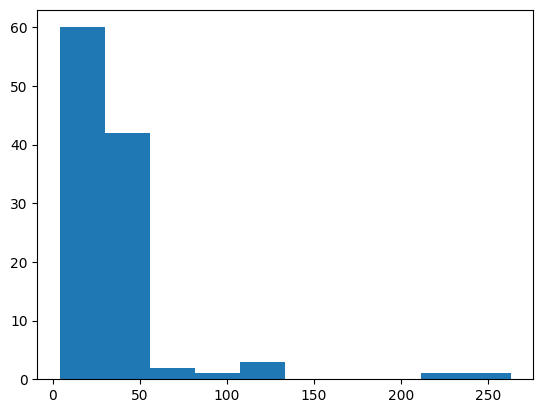

In [19]:
plt.hist(conditions_per_patient["nb"])

In [17]:
cpp_ordered = conditions_per_patient.sort_values(by=["nb"], ascending=False)
cpp_ordered.head()

,person_id,nb
95,5846,263
107,5858,223
71,5822,130
74,5825,125
108,5859,110
